In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
import seaborn as sns

In [3]:
df_medicaid_new = pd.read_csv('data/datasets/usa_00001.csv.gz')

In [4]:
df_medicaid_new.columns

Index(['YEAR', 'SAMPLE', 'SERIAL', 'CBSERIAL', 'HHWT', 'CLUSTER', 'STATEFIP',
       'STRATA', 'GQ', 'PERNUM', 'PERWT', 'RELATE', 'RELATED', 'SEX', 'AGE',
       'HINSCAID', 'EMPSTAT', 'EMPSTATD', 'UHRSWORK', 'INCWAGE'],
      dtype='str')

In [5]:
statefip_to_name = {
    1: "Alabama",
    12: "Florida",
    13: "Georgia",
    20: "Kansas",
    28: "Mississippi",
    30: "Montana",
    37: "North Carolina",
    45: "South Carolina",
    46: "South Dakota",
    47: "Tennessee",
    48: "Texas",
    55: "Wisconsin",
    56: "Wyoming",
}

In [6]:
#AGE FILTERN
df_medicaid_2 = df_medicaid_new[df_medicaid_new['AGE'].between(18,65)]
#RELATE FILTERN
df_medicaid_2 = df_medicaid_2[df_medicaid_2['RELATE'].isin([1,2])]
#TOP ENCODING UHRSWORK, INCWAGE
df_medicaid_2 = df_medicaid_2[(df_medicaid_2['INCWAGE'] > 0) & (df_medicaid_2['INCWAGE'] < 999999)]
df_medicaid_2 = df_medicaid_2[(df_medicaid_2['UHRSWORK'] > 0) & (df_medicaid_2['UHRSWORK'] < 999999)]
#LOG TAFO
df_medicaid_2['INCWAGE'] = np.log(df_medicaid_2['INCWAGE'])
df_medicaid_2['UHRSWORK'] = np.log(df_medicaid_2['UHRSWORK'])
#EMPSTAT filtern
#df_medicaid_2 = df_medicaid_2[df_medicaid_2['EMPSTAT'].isin([1,2])]

df_medicaid_2 = df_medicaid_2[df_medicaid_2['STATEFIP'].isin(statefip_to_name.keys())]

In [7]:
df_medicaid_2[df_medicaid_2['YEAR'] <= 2016].groupby('STATEFIP').size()

STATEFIP
1     105341
12    418434
13    223864
20     72923
28     60580
30     23995
37    229984
45    106521
46     21134
47    148029
48    580639
55    153421
56     15567
dtype: int64

In [8]:
df_medicaid = pd.read_csv('data/datasets/medicaid.csv')

In [9]:
df_dube = pd.read_csv('data/datasets/dube_combined.csv')

In [10]:
df_cps = pd.read_csv('data/datasets/cps_00001.csv.gz')

In [11]:
df_cps.dropna(subset=['INCWAGE'], inplace=True)
df_cps = df_cps[df_cps['INCWAGE'] > 0.0]

In [12]:
states_list = [42,  # Pennsylvania
18,  # Indiana
55,  # Wisconsin
20,  # Kansas
51,  # Virginia
37,  # North Carolina
48,  # Texas
49,  # Utah
34,  # New Jersey
]

In [20]:
df_cps = df_cps[df_cps['STATEFIP'].isin(states_list)]

In [21]:
df_cps.columns

Index(['YEAR', 'SERIAL', 'MONTH', 'HWTFINL', 'CPSID', 'ASECFLAG', 'HFLAG',
       'ASECWTH', 'STATEFIP', 'PERNUM', 'WTFINL', 'CPSIDP', 'CPSIDV', 'ASECWT',
       'RELATE', 'AGE', 'SEX', 'UHRSWORKLY', 'FULLPART', 'FIRMSIZE', 'INCWAGE',
       'INCSS', 'OFFPOV'],
      dtype='str')

<Axes: >

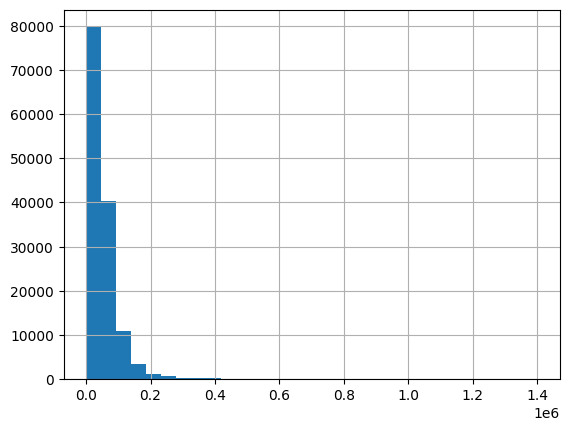

In [26]:
(df_cps['INCWAGE']).hist(bins = 30)

## Medicaid Dataset

In [19]:
df_medicaid_2 = pd.read_csv('data/datasets/medicaid_pre.csv')

1733
1733
Sind die Counts identisch? True


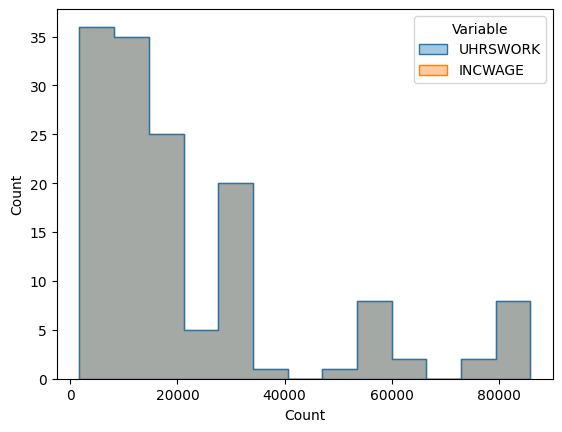

In [4]:
df_size_comp = df_medicaid.groupby(['YEAR','STATEFIP'])[['UHRSWORK','INCWAGE']].count().reset_index()

print(df_size_comp['UHRSWORK'].min())
print(df_size_comp['INCWAGE'].min())

# Die Spalten UHRSWORK und INCWAGE "schmelzen", um sie in einer Spalte 'Variable' und einer Spalte 'Count' unterzubringen
long_df = df_size_comp.melt(
    id_vars=['YEAR', 'STATEFIP'],       # Spalten, die erhalten bleiben sollen
    value_vars=['UHRSWORK', 'INCWAGE'], # Spalten, die untereinander geschrieben werden sollen
    var_name='Variable',
    value_name='Count'                  # Name für die neue Werte-Spalte
)

sns.histplot(data=long_df, x='Count', hue='Variable', element="step", alpha=0.4)
is_identical = (df_size_comp['UHRSWORK'] == df_size_comp['INCWAGE']).all()
print("Sind die Counts identisch?", is_identical)

In [5]:
print('Unique Years:')
print(df_medicaid['YEAR'].unique())

print('Unique FIPS:')
print(df_medicaid['STATEFIP'].unique())

Unique Years:
[2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020]
Unique FIPS:
[ 1 12 13 20 28 30 37 45 46 47 48 55 56]


In [6]:
pd.crosstab(df_medicaid['YEAR'], df_medicaid['STATEFIP'])

STATEFIP,1,12,13,20,28,30,37,45,46,47,48,55,56
YEAR,,,,,,,,,,,,,
2010,15121,58784,32145,10172,8676,3348,32277,15029,2868,20848,79793,21891,2121
2011,14481,57783,29345,9931,8332,3293,30502,14354,2794,19724,76097,21156,2137
2012,14400,56738,30422,10076,8218,3273,31568,14446,2855,20075,77917,21012,2071
2013,14365,57462,30728,10204,8331,3234,31543,14504,2913,20490,80328,21013,2187
2014,14176,57140,30664,9821,8121,3118,31496,14485,2912,20088,80174,20737,2082
2015,14106,57256,30993,9920,8264,3149,31604,14645,2926,20483,81454,20825,2078
2016,14273,58084,31257,9896,8174,3224,31852,14897,2995,20307,82370,20607,2036
2017,14204,59692,32005,9966,8208,3286,32684,15171,2978,21051,83824,20944,2039
2018,14218,60160,32492,10041,8380,3213,33145,15246,2998,21145,84297,20987,1954


count    2.076064e+06
mean     3.424853e+00
std      8.056840e-01
min     -2.659260e+00
25%      2.982647e+00
50%      3.453157e+00
75%      3.925926e+00
max      6.830982e+00
Name: UHRSWORK, dtype: float64


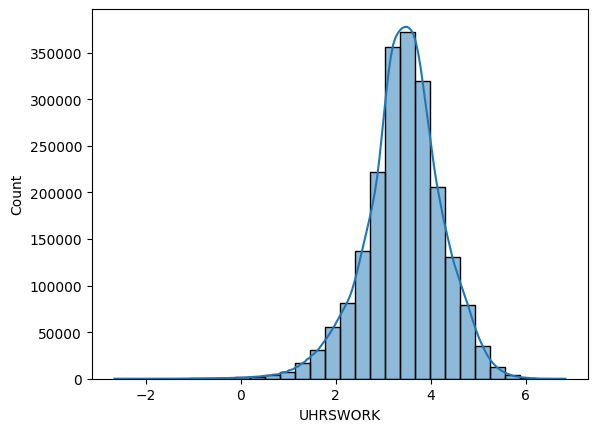

In [9]:
sns.histplot(df_medicaid['UHRSWORK'], bins=30, kde=True)
print(df_medicaid['UHRSWORK'].describe())

count    2.076064e+06
mean     1.018294e+01
std      1.212381e+00
min     -8.338161e-02
25%      9.510445e+00
50%      1.028517e+01
75%      1.097507e+01
max      1.530038e+01
Name: INCWAGE, dtype: float64


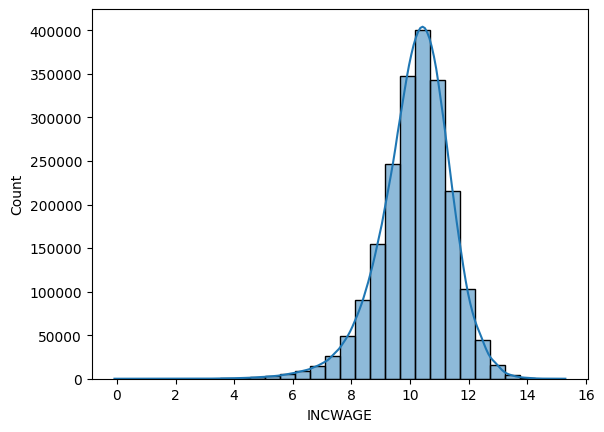

In [10]:
sns.histplot(df_medicaid['INCWAGE'], bins=30, kde=True)
print(df_medicaid['INCWAGE'].describe())

### Preprocessing

In [21]:
statefip_to_name = {
    1: "Alabama",
    12: "Florida",
    13: "Georgia",
    20: "Kansas",
    28: "Mississippi",
    30: "Montana",
    37: "North Carolina",
    45: "South Carolina",
    46: "South Dakota",
    47: "Tennessee",
    48: "Texas",
    55: "Wisconsin",
    56: "Wyoming",
}

In [23]:
df_medicaid_2['STATE'] = df_medicaid['STATEFIP'].replace(statefip_to_name)
df_medicaid_preprocesses = df_medicaid[df_medicaid['YEAR'].between(2010,2017)]

In [24]:
df_medicaid_preprocesses.groupby('STATE').size()

STATE
Alabama           115126
Florida           462939
Georgia           247559
Kansas             79986
Mississippi        66324
Montana            25925
North Carolina    253526
South Carolina    117531
South Dakota       23241
Tennessee         163066
Texas             641957
Wisconsin         168185
Wyoming            16751
dtype: int64

## Dube Data

In [51]:
df_dube.info()

<class 'pandas.DataFrame'>
RangeIndex: 12919291 entries, 0 to 12919290
Data columns (total 64 columns):
 #   Column         Dtype  
---  ------         -----  
 0   _child18       int64  
 1   _fam18         int64  
 2   oldfaminc      int64  
 3   oldpovcut      int64  
 4   age            int64  
 5   hhseq          int64  
 6   income         int64  
 7   marstat        int64  
 8   sex            int64  
 9   wtsupp         int64  
 10  year           int64  
 11  fips           int64  
 12  division       int64  
 13  race           int64  
 14  hispan         int64  
 15  nchild         int64  
 16  agesq          int64  
 17  agecub         float64
 18  agequart       float64
 19  pf_nunder18    int64  
 20  hh_nunder18    int64  
 21  educ           int64  
 22  faminc         float64
 23  povcut         float64
 24  contpov        float64
 25  credits        int64  
 26  transfers      float64
 27  famadj0inc     float64
 28  famadj1inc     float64
 29  famadj2inc     float64


1190
1190


<Axes: xlabel='Count', ylabel='Count'>

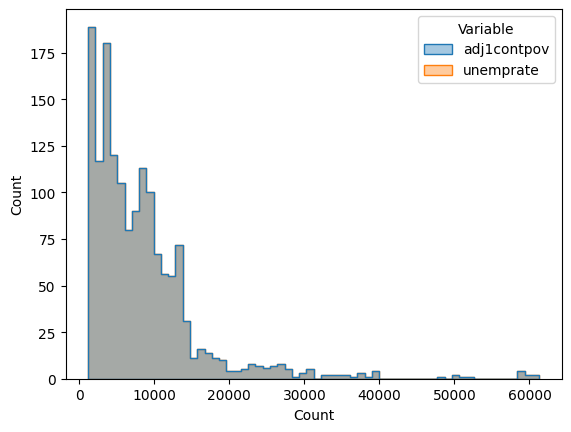

In [6]:
df_size_comp = df_dube.groupby(['year','fips'])[['adj1contpov','unemprate']].count().reset_index()

print(df_size_comp['adj1contpov'].min())
print(df_size_comp['unemprate'].min())

# Die Spalten UHRSWORK und INCWAGE "schmelzen", um sie in einer Spalte 'Variable' und einer Spalte 'Count' unterzubringen
long_df = df_size_comp.melt(
    id_vars=['year','fips'],       # Spalten, die erhalten bleiben sollen
    value_vars=['adj1contpov','unemprate'], # Spalten, die untereinander geschrieben werden sollen
    var_name='Variable',
    value_name='Count'                  # Name für die neue Werte-Spalte
)

sns.histplot(data=long_df, x='Count', hue='Variable', element="step", alpha=0.4)

In [54]:
print('Unique Years:')
print(df_dube['year'].unique())

print('Unique FIPS:')
print(df_dube['fips'].unique())

Unique Years:
[1984 1985 1986 1987 1988 1989 1990 1991 1992 1993 1994 1995 1996 1997
 1998 1999 2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011
 2012 2013]
Unique FIPS:
[ 1  2  4  5  6  8  9 10 11 12 13 15 16 17 18 19 20 21 22 23 24 25 26 27
 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 44 45 46 47 48 49 50 51 53
 54 55 56]


count    1.291929e+07
mean     3.875998e+00
std      3.817827e+00
min      0.000000e+00
25%      1.642082e+00
50%      2.975109e+00
75%      4.895246e+00
max      1.000000e+02
Name: adj1contpov, dtype: float64


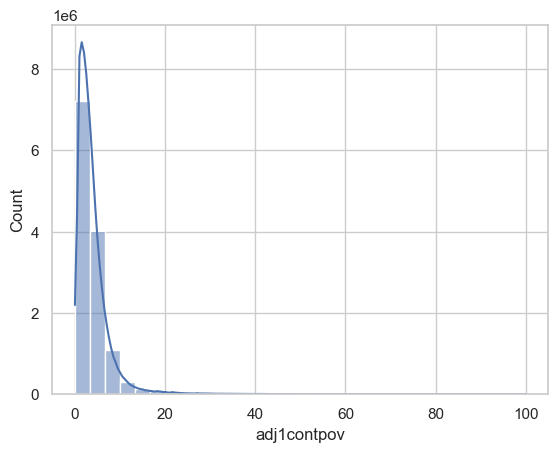

In [56]:
sns.histplot(df_dube['adj1contpov'], bins=30, kde=True)
print(df_dube['adj1contpov'].describe())

count    1.291929e+07
mean     5.995250e+00
std      2.064029e+00
min      2.300000e+00
25%      4.500000e+00
50%      5.500000e+00
75%      7.100000e+00
max      1.740000e+01
Name: unemprate, dtype: float64


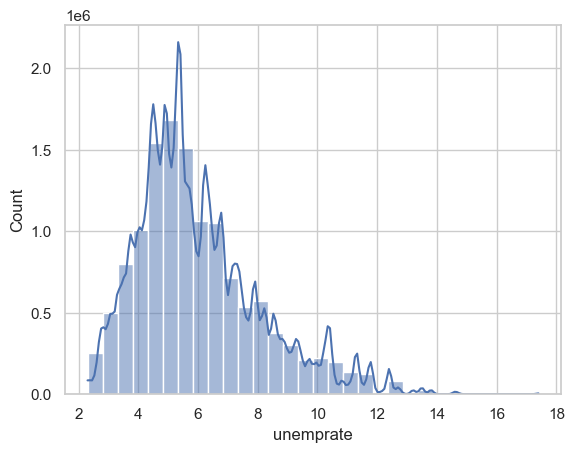

In [57]:
sns.histplot(df_dube['unemprate'], bins=30, kde=True)
print(df_dube['unemprate'].describe())

## CPS Dataset

In [10]:
import openpyxl
cps_metadata = pd.read_excel('data/datasets/matchedCPS_1979_2016_metadata.xlsx')
cps_metadata[cps_metadata['Column'].str.contains('state')]

,Column,describtion
3,state_1,State
43,statenum_1,State FIPS code
71,statenum,NaN
73,state,State


In [161]:
cps_metadata[cps_metadata['describtion'].str.contains('wt')]

,Column,describtion


In [162]:
cps_metadata[cps_metadata['Column'].str.contains('wt')]

,Column,describtion
20,earnwt_1,(dp) Earnings weight for all races x100
46,orgwt_1,NaN
88,earnwt,(dp) Earnings weight for all races x100
113,orgwt,NaN


In [12]:
cps_metadata[cps_metadata['Column'].str.contains('hour')]

,Column,describtion
17,uhours_1,(dp) Usual hours
21,uhourse_1,(e&dp) Usual hours
54,hoursimputed_1,NaN
85,uhours,(dp) Usual hours
89,uhourse,(e&dp) Usual hours
121,hoursimputed,NaN


In [23]:
cps_metadata[cps_metadata['describtion'].str.contains('weight')]

,Column,describtion
20,earnwt_1,(dp) Earnings weight for all races x100
88,earnwt,(dp) Earnings weight for all races x100


In [ ]:
df_cps['earnwt']

count    3.640481e+06
mean     7.812003e+03
std      4.318770e+03
min      0.000000e+00
25%      4.597664e+03
50%      7.461718e+03
75%      1.076512e+04
max      1.105785e+05
Name: earnwt, dtype: float64

121
68


<Axes: xlabel='Count', ylabel='Count'>

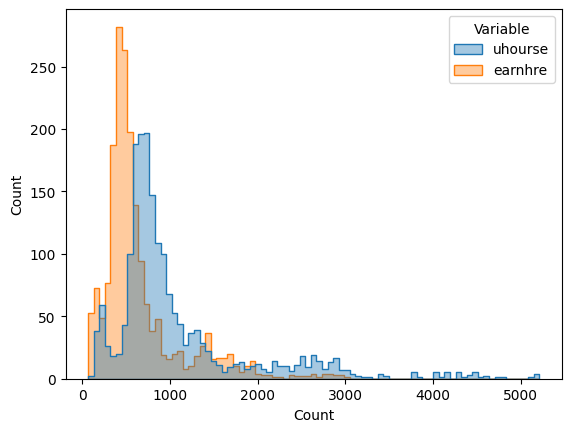

In [21]:
df_size_comp = df_cps.groupby(['year','statenum'])[['uhourse','earnhre']].count().reset_index()
df_size_comp = df_size_comp[(df_size_comp['uhourse'] > 0) & (df_size_comp['earnhre'] > 0)]

print(df_size_comp['uhourse'].min())
print(df_size_comp['earnhre'].min())

# Die Spalten UHRSWORK und INCWAGE "schmelzen", um sie in einer Spalte 'Variable' und einer Spalte 'Count' unterzubringen
long_df = df_size_comp.melt(
    id_vars=['year','statenum'],       # Spalten, die erhalten bleiben sollen
    value_vars=['uhourse','earnhre'], # Spalten, die untereinander geschrieben werden sollen
    var_name='Variable',
    value_name='Count'                  # Name für die neue Werte-Spalte
)

sns.histplot(data=long_df, x='Count', hue='Variable', element="step", alpha=0.4)

In [84]:
print('Unique Years:')
print(df_cps['year'].unique())

print('Unique FIPS:')
print(df_cps['statenum'].unique())

Unique Years:
[1980 1981 1982 1983 1984 1985 1986 1987 1988 1989 1990 1991 1992 1993
 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003 2004 2005 2006 2007
 2008 2009 2010 2011 2012 2013 2014 2015 2016]
Unique FIPS:
[36. 51. 32. 12. 26. 20. 54. 23. 17. 22.  5. 35.  8. 56. 39.  6.  1. 55.
 30.  4. 45. 33. 28. 25. 48. 31. 16. 13. 47.  9. 29. 18. 24.  2. 40. 49.
 21. 19. 27. 38. 46. 37. 50. 34. 53. 15. 10. 42. 41. 44. 11.]


count    2.024333e+06
mean     3.833992e+01
std      1.044748e+01
min      0.000000e+00
25%      3.900000e+01
50%      4.000000e+01
75%      4.000000e+01
max      9.900000e+01
Name: uhourse, dtype: float64


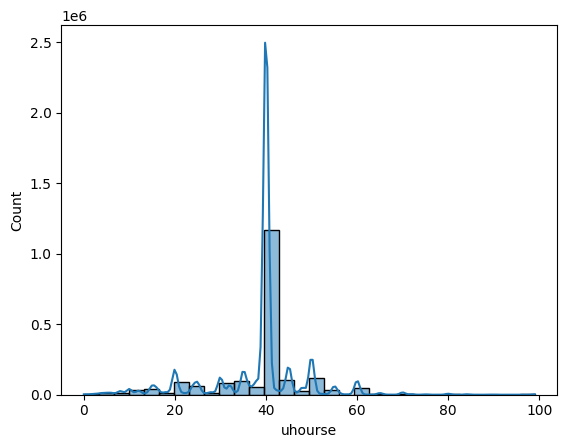

In [25]:
sns.histplot(df_cps['uhourse'], bins=30, kde=True)
print(df_cps['uhourse'].describe())

count    1.233270e+06
mean     1.177013e+03
std      7.923060e+02
min      2.000000e+00
25%      6.750000e+02
50%      1.000000e+03
75%      1.475000e+03
max      9.999000e+03
Name: earnhre, dtype: float64


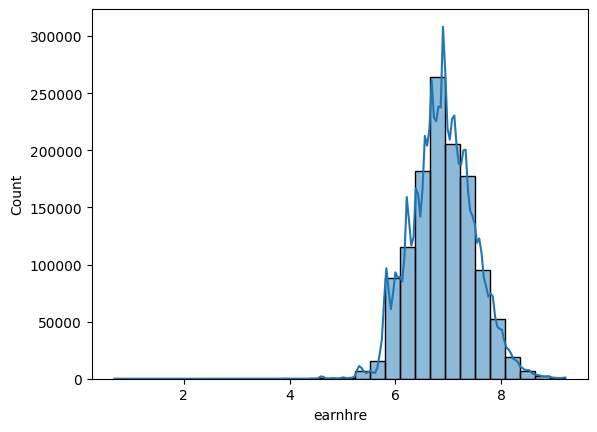

In [31]:
import numpy as np
sns.histplot(np.log(df_cps['earnhre']), bins=30, kde=True)
print(df_cps['earnhre'].describe())

In [118]:
#possible setup
donors = [23,32,35,47,54,56,74,87]
target = 22

states_oi = donors + [target]

df_cps_oi = df_cps[df_cps['state'].isin(states_oi)]

In [145]:
df_cps_oi_2014 = df_cps_oi[df_cps_oi['year'] == 2014].copy()
df_cps_oi_2013 = df_cps_oi[df_cps_oi['year_1'] == 2013].copy()

df_cps_oi_2013 = df_cps_oi_2013[(df_cps_oi_2013['earnhre'].notna())]
df_cps_oi_2013 = df_cps_oi_2013[(df_cps_oi_2013['uhourse'].notna())]
df_cps_oi_2013 = df_cps_oi_2013[(df_cps_oi_2013['earnwt'].notna())]

df_cps_oi_2014 = df_cps_oi_2014[(df_cps_oi_2014['earnhre'].notna())]
df_cps_oi_2014 = df_cps_oi_2014[(df_cps_oi_2014['uhourse'].notna())]
df_cps_oi_2014 = df_cps_oi_2014[(df_cps_oi_2014['earnwt'].notna())]

In [189]:
pd.crosstab(df_cps_oi_2013['year_1'], df_cps_oi_2013['state'])

state,22.0,23.0,32.0,35.0,47.0,54.0,56.0,74.0,87.0
year_1,,,,,,,,,
2013,136,310,144,232,136,151,132,426,99


In [166]:
df_cps_oi_2014 = df_cps_oi_2014[df_cps_oi_2014['age'].between(18,65) ]

In [167]:
pd.crosstab(df_cps_oi_2014['year'], df_cps_oi_2014['state'])

state,22.0,23.0,32.0,35.0,47.0,54.0,56.0,74.0,87.0
year,,,,,,,,,
2014,129,300,134,217,120,141,126,411,90


# Auswertung Merdicaid

In [ ]:
import joblib
metrics_energy = joblib.load("../results/metrics/medicaid_12_2014_energy_metrics.pkl")
metrics_mixture = joblib.load("../results/metrics/medicaid_12_2014_mixture_metrics.pkl")

metrics_swasserstein = joblib.load("../results/metrics/medicaid_12_2014_swasserstein_metrics.pkl")
metrics_tangential = joblib.load("../results/metrics/medicaid_12_2014_tangential_metrics.pkl")


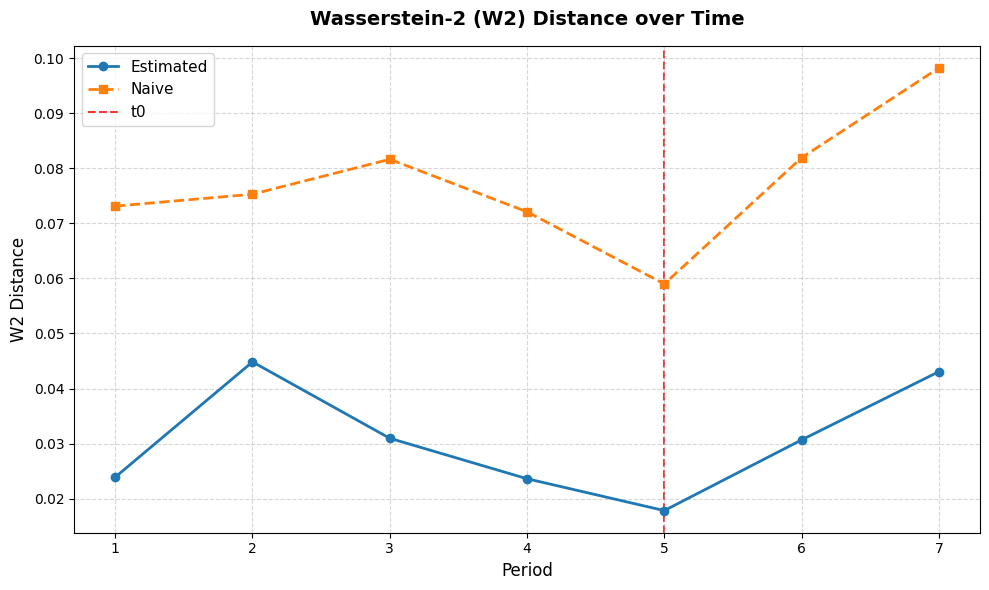

In [66]:
periods_energy = range(1, len(metrics_energy['est_metrics_list'][0])+1)
w2_energy = [value['w2'] for key, value in metrics_energy['est_metrics_list'][0].items()]
w2_energy_naive = [value['w2'] for key, value in metrics_energy['naive_metrics_list'][0].items()]

fig, ax = plt.subplots(figsize=(10, 6))

# Linien zeichnen mit klaren Labels, Farben und Markern zur besseren Unterscheidbarkeit
ax.plot(periods_energy, w2_energy, label='Estimated', marker='o', linewidth=2)
ax.plot(periods_energy, w2_energy_naive, label='Naive', marker='s', linestyle='--', linewidth=2)

# Vertikale gestrichelte Linie bei x=5
ax.axvline(x=5, color='red', linestyle='--', linewidth=1.5, alpha=0.8, label='t0', zorder=1)

# Beschriftungen und Styling
ax.set_title('Wasserstein-2 (W2) Distance over Time', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Period', fontsize=12)
ax.set_ylabel('W2 Distance', fontsize=12)

# Hilfsraster für bessere Lesbarkeit der quantitativen Werte
ax.grid(True, linestyle='--', alpha=0.5)

# Legende aktivieren
ax.legend(fontsize=11, loc='best')

# Sorgt dafür, dass nichts abgeschnitten wird
plt.tight_layout()
plt.show()

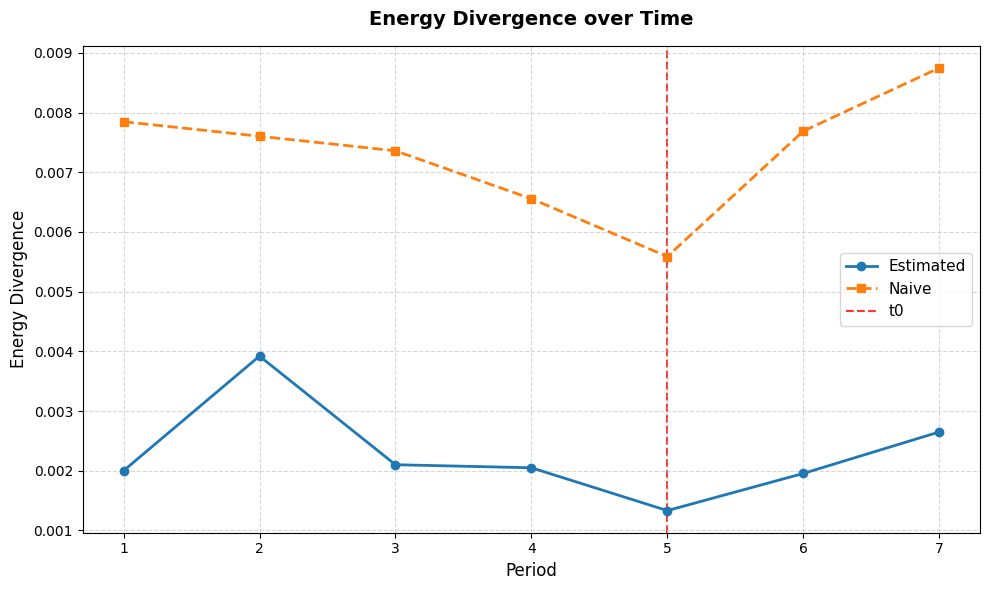

In [69]:
periods_energy = range(1, len(metrics_energy['est_metrics_list'][0])+1)
w2_energy = [value['energy_divergence'] for key, value in metrics_energy['est_metrics_list'][0].items()]
w2_energy_naive = [value['energy_divergence'] for key, value in metrics_energy['naive_metrics_list'][0].items()]

fig, ax = plt.subplots(figsize=(10, 6))

# Linien zeichnen mit klaren Labels, Farben und Markern zur besseren Unterscheidbarkeit
ax.plot(periods_energy, w2_energy, label='Estimated', marker='o', linewidth=2)
ax.plot(periods_energy, w2_energy_naive, label='Naive', marker='s', linestyle='--', linewidth=2)

# Vertikale gestrichelte Linie bei x=5
ax.axvline(x=5, color='red', linestyle='--', linewidth=1.5, alpha=0.8, label='t0', zorder=1)

# Beschriftungen und Styling
ax.set_title('Energy Divergence over Time', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Period', fontsize=12)
ax.set_ylabel('Energy Divergence', fontsize=12)

# Hilfsraster für bessere Lesbarkeit der quantitativen Werte
ax.grid(True, linestyle='--', alpha=0.5)

# Legende aktivieren
ax.legend(fontsize=11, loc='best')

# Sorgt dafür, dass nichts abgeschnitten wird
plt.tight_layout()
plt.show()